1. Find slow-adapting players

2. Plot their session trajectories

3. Colour session trajectories by performance over specific window

4. Check whether slow-adapting player do better toward the end of the session 

In [42]:
import sys
import os

sys.path.append('/Users/benny/Repos/octagon_analysis')

import pandas as pd
import numpy as np
import parse_data.identify_filepaths as identify_filepaths
import globals

In [10]:
occupancy_dict = pd.read_pickle('/Users/benny/Documents/swc/pickled_df/occupancy_dict.pkl') 

In [9]:
trait_df = pd.read_pickle('/Users/benny/Documents/swc/trait_analyses/trait_dataframes/df2.csv') 

In [8]:
social_lists = pd.read_pickle('/Users/benny/Documents/swc/pickled_df/social_lists.pkl')

In [11]:
data_folder = '/Volumes/ogma/human_octagon/RAW/standard'
json_filenames_social, json_filenames_solo = identify_filepaths.get_filenames(data_folder)

In [28]:
def get_pseudonyms_from_social_filename(filename):
    """
    Example:
    '240913_1/2024-09-13_11-31-00_YW13_JL13_Social.json'
    returns ('YW13', 'JL13')
    """
    base = os.path.basename(filename)
    stem = base.replace('.json', '')
    parts = stem.split('_')

    player0_pseudonym = parts[-3]
    player1_pseudonym = parts[-2]

    return player0_pseudonym, player1_pseudonym

In [45]:
def get_rolling_score_metrics_by_pseudonym(trial_lists, json_filenames_social):

    rolling_metrics = {}

    for session_idx, trial_list in enumerate(trial_lists):

        player0_pseudonym, player1_pseudonym = (
            get_pseudonyms_from_social_filename(
                json_filenames_social[session_idx]
            )
        )

        pseudonyms = {
            0: player0_pseudonym,
            1: player1_pseudonym
        }

        player0_prop = []
        player1_prop = []

        player0_adv = []
        player1_adv = []

        for trial in trial_list:

            trial_end = trial[
                trial['eventDescription'] == 'trial end'
            ]

            score0 = trial_end[
                globals.PLAYER_SCORE_DICT[0]['score']
            ].item()

            score1 = trial_end[
                globals.PLAYER_SCORE_DICT[1]['score']
            ].item()

            total = score0 + score1

            if total == 0:
                prop0 = prop1 = np.nan
                adv0 = adv1 = np.nan
            else:
                prop0 = score0 / total
                prop1 = score1 / total

                adv0 = (score0 - score1) / total
                adv1 = (score1 - score0) / total

            player0_prop.append(prop0)
            player1_prop.append(prop1)

            player0_adv.append(adv0)
            player1_adv.append(adv1)

        for player_idx in [0, 1]:

            pseudonym = pseudonyms[player_idx]

            if player_idx == 0:
                prop = player0_prop
                adv = player0_adv
                opponent = player1_pseudonym
            else:
                prop = player1_prop
                adv = player1_adv
                opponent = player0_pseudonym

            rolling_metrics[pseudonym] = {
                'session_idx': session_idx,
                'player_idx': player_idx,
                'opponent': opponent,
                'proportion_score': prop,
                'score_advantage': adv,
            }

    return rolling_metrics

In [82]:
# 10 representative slow-adapting participants

ui = pd.Series(
    occupancy_dict['understanding_index']
)

slow_adapters = ui.nsmallest(10)
#fast_adapters = ui.nlargest(10)

pseudonyms = slow_adapters.index.tolist()
#pseudonyms = fast_adapters.index.tolist()

# 1. rolling proportion score
rolling_metrics_by_pseudonym = get_rolling_score_metrics_by_pseudonym(
    social_lists,
    json_filenames_social
)

for pseudo in pseudonyms:
    # 1. rolling proportion score
    proportion_score = rolling_metrics_by_pseudonym[pseudo]['proportion_score']
    score_advantage = rolling_metrics_by_pseudonym[pseudo]['score_advantage']
    opponent = rolling_metrics_by_pseudonym[pseudo]['opponent']

    # 2. player centrality vs trial
    trial_by_trial_centrality = occupancy_dict['socials']['raw_values'][pseudo]
    # remember to get rid of the first trial after

    # 3. opponent centrality vs trial
    opponent = trait_df.loc[pseudo]['opponent']
    trial_by_trial_centrality_opp = occupancy_dict['socials']['raw_values'][opponent]



In [80]:
def plot_slow_adapter_session(
    pseudo,
    occupancy_dict,
    rolling_metrics_by_pseudonym,
    trait_df=None,
    drop_first_trial=True,
    smooth_window=None,
    use_trait_df_opponent=False
):
    proportion_score = np.asarray(
        rolling_metrics_by_pseudonym[pseudo]['proportion_score'],
        dtype=float
    )

    score_advantage = np.asarray(
        rolling_metrics_by_pseudonym[pseudo]['score_advantage'],
        dtype=float
    )

    if use_trait_df_opponent and trait_df is not None:
        opponent = trait_df.loc[pseudo]['opponent']
    else:
        opponent = rolling_metrics_by_pseudonym[pseudo]['opponent']

    player_centrality = np.asarray(
        occupancy_dict['socials']['raw_values'][pseudo],
        dtype=float
    )

    opponent_centrality = np.asarray(
        occupancy_dict['socials']['raw_values'][opponent],
        dtype=float
    )

    # Align lengths safely
    n = min(
        len(player_centrality),
        len(opponent_centrality),
        len(proportion_score),
        len(score_advantage)
    )

    player_centrality = player_centrality[:n]
    opponent_centrality = opponent_centrality[:n]
    proportion_score = proportion_score[:n]
    score_advantage = score_advantage[:n]

    if drop_first_trial:
        player_centrality = player_centrality[1:]
        opponent_centrality = opponent_centrality[1:]
        proportion_score = proportion_score[1:]
        score_advantage = score_advantage[1:]

    centrality_diff = player_centrality - opponent_centrality
    trials = np.arange(1, len(player_centrality) + 1)

    def smooth(x, window):
        if window is None or window <= 1:
            return x
        return (
            np.convolve(
                x,
                np.ones(window) / window,
                mode='same'
            )
        )

    plot_prop = smooth(proportion_score, smooth_window)
    plot_adv = smooth(score_advantage, smooth_window)

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(10, 7),
        sharex=True,
        gridspec_kw={'height_ratios': [2, 1, 1]}
    )

    axes[0].plot(trials, player_centrality, label=f'{pseudo} centrality', color='dodgerblue')
    axes[0].plot(trials, opponent_centrality, label=f'{opponent} centrality', color='crimson')
    axes[0].set_ylabel('centrality', fontsize=20)
    axes[0].tick_params(axis='both',labelsize=20)
    axes[0].legend(frameon=False)
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)

    axes[1].axhline(0, linestyle='--', linewidth=1)
    axes[1].plot(trials, centrality_diff, color='darkslateblue')
    axes[1].set_ylabel('player - opponent\ncentrality', fontsize=20)
    axes[1].tick_params(axis='both',labelsize=20)
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)

    axes[2].axhline(0, linestyle='--', linewidth=1)
    axes[2].plot(trials, plot_adv, label='score advantage', color='blueviolet')
    axes[2].plot(trials, plot_prop, label='proportion score', color='orangered')
    axes[2].set_ylabel('performance', fontsize=20)
    axes[2].set_xlabel('social trial', fontsize=20)
    axes[2].legend(frameon=False)
    axes[2].tick_params(axis='both',labelsize=20)
    axes[2].spines['top'].set_visible(False)
    axes[2].spines['right'].set_visible(False)

    ui = occupancy_dict['understanding_index'].get(pseudo, np.nan)

    fig.suptitle(
        f'{pseudo} vs {opponent} | adaptation index = {ui:.2f}',
        y=1.02,
        fontsize=20
    )

    plt.tight_layout()
    plt.show()

In [50]:
import matplotlib.pyplot as plt

In [85]:
fast_adapters

CY17    4.921654
EM17    4.897800
RU10    3.620563
JL19    3.439600
MO05    2.448126
CW17    2.160678
SJ18    2.091459
AS19    2.058078
EL16    2.030116
RD13    1.945912
dtype: float64

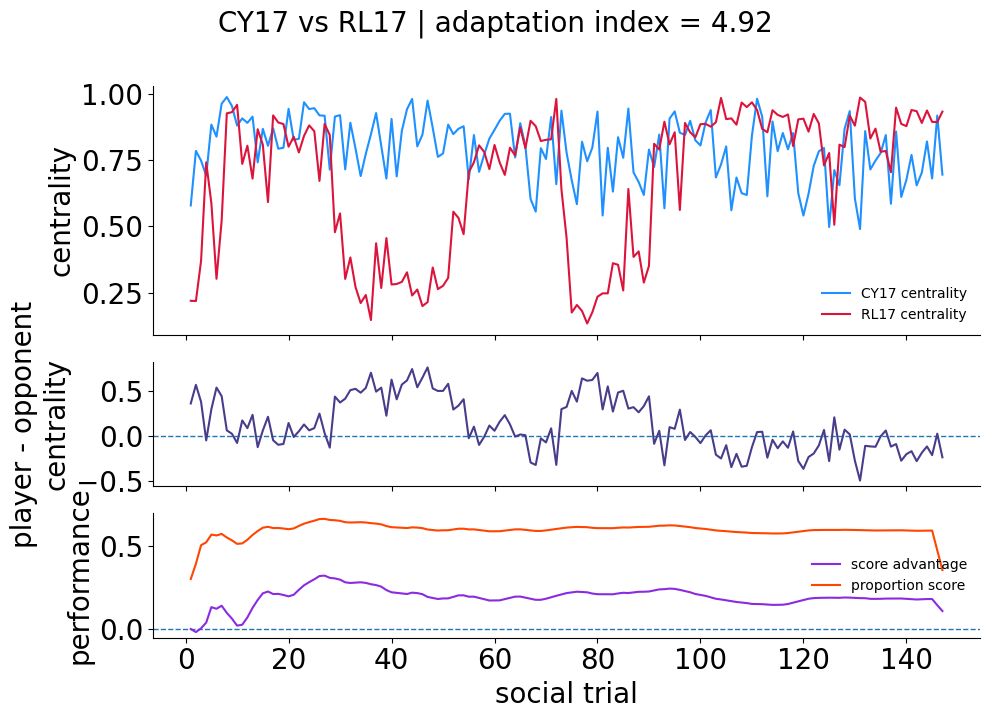

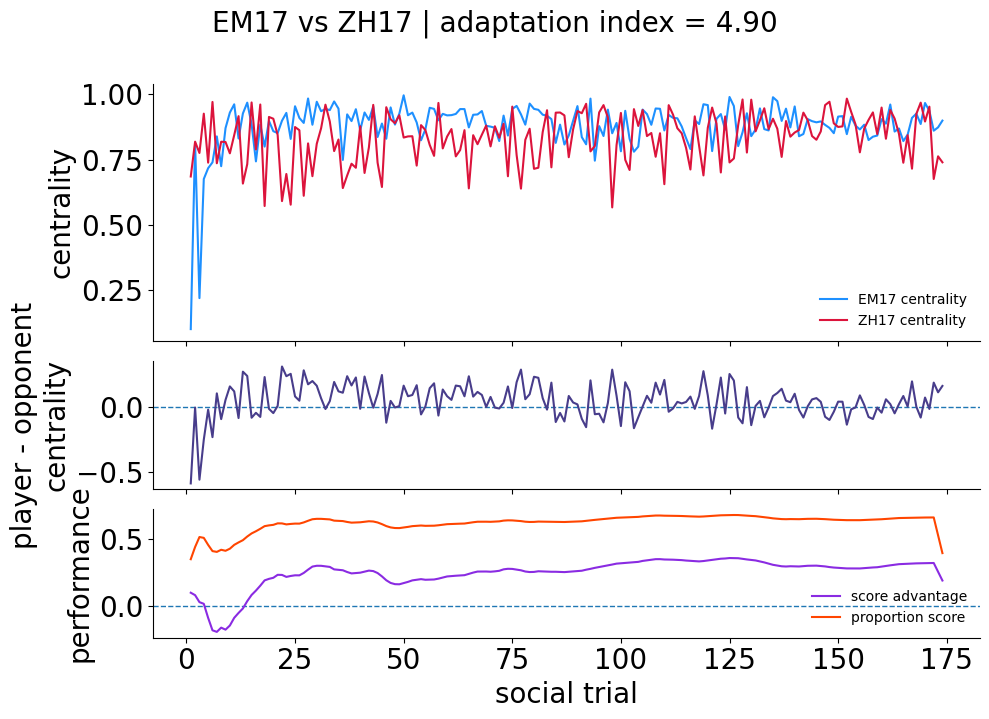

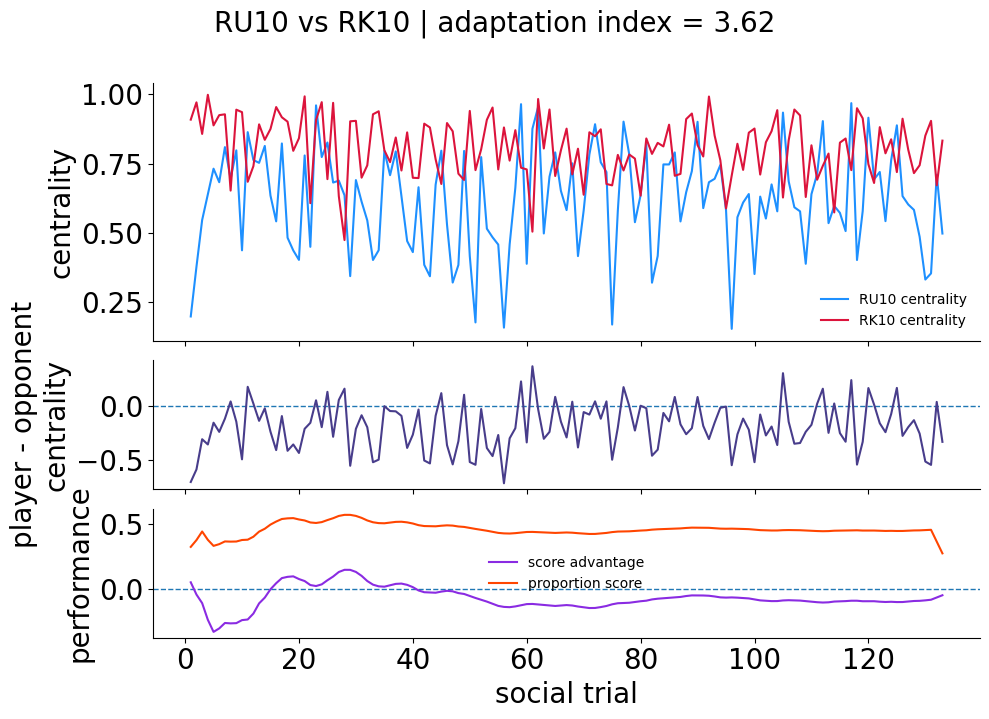

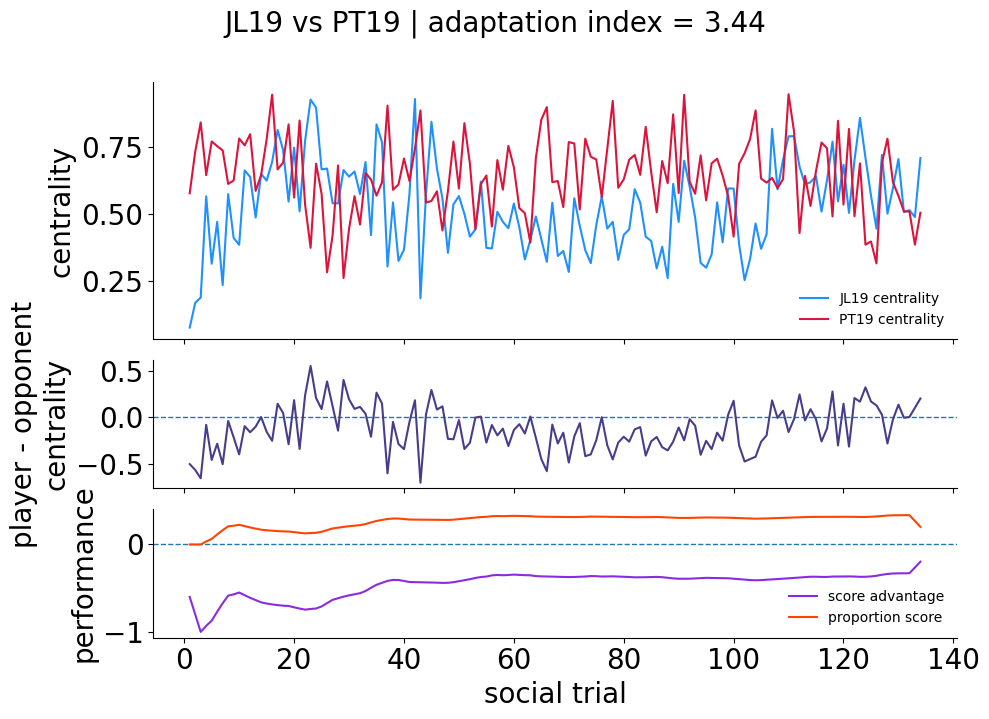

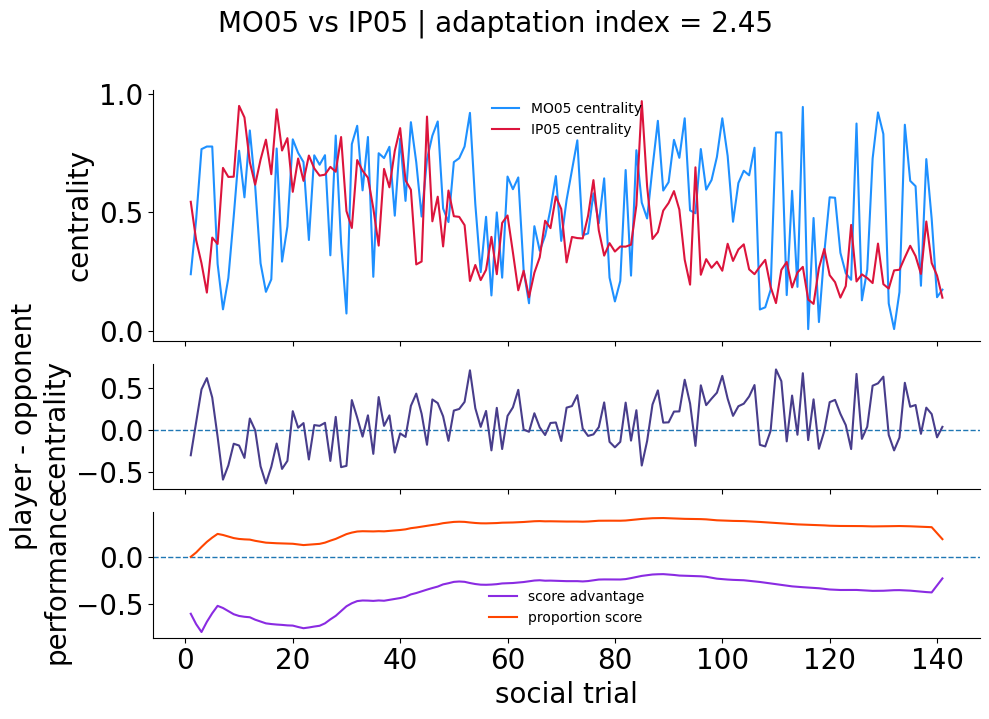

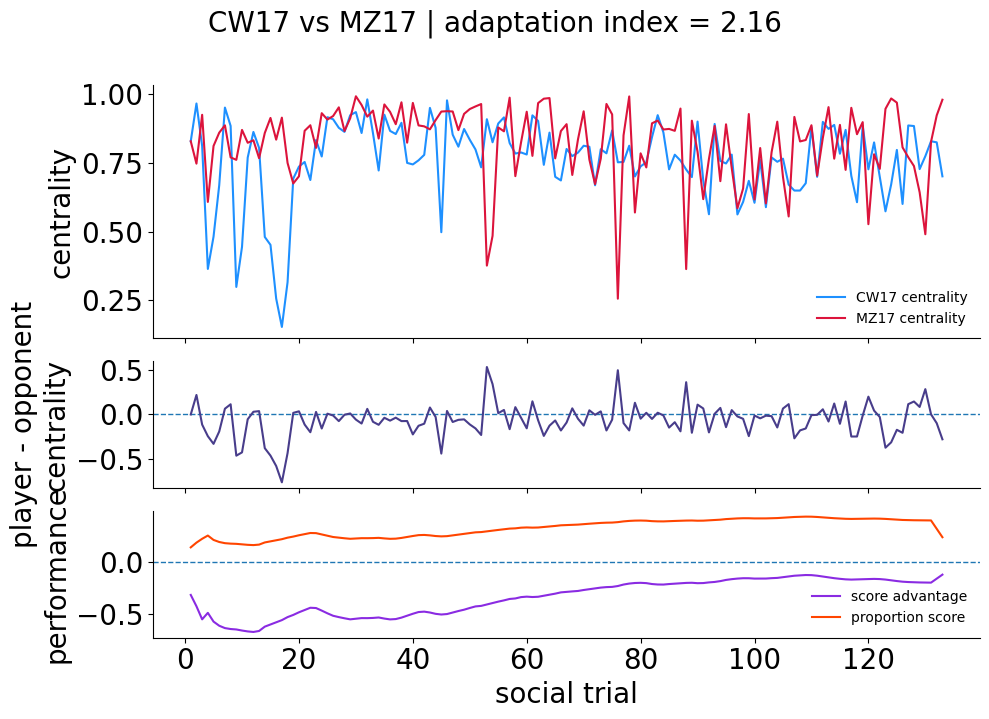

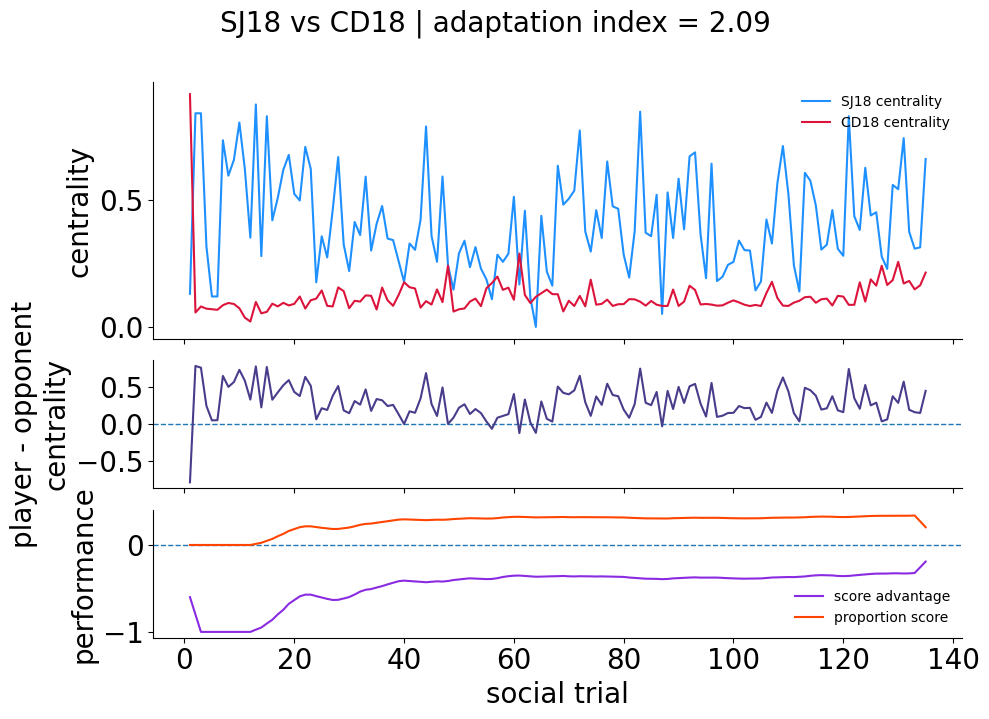

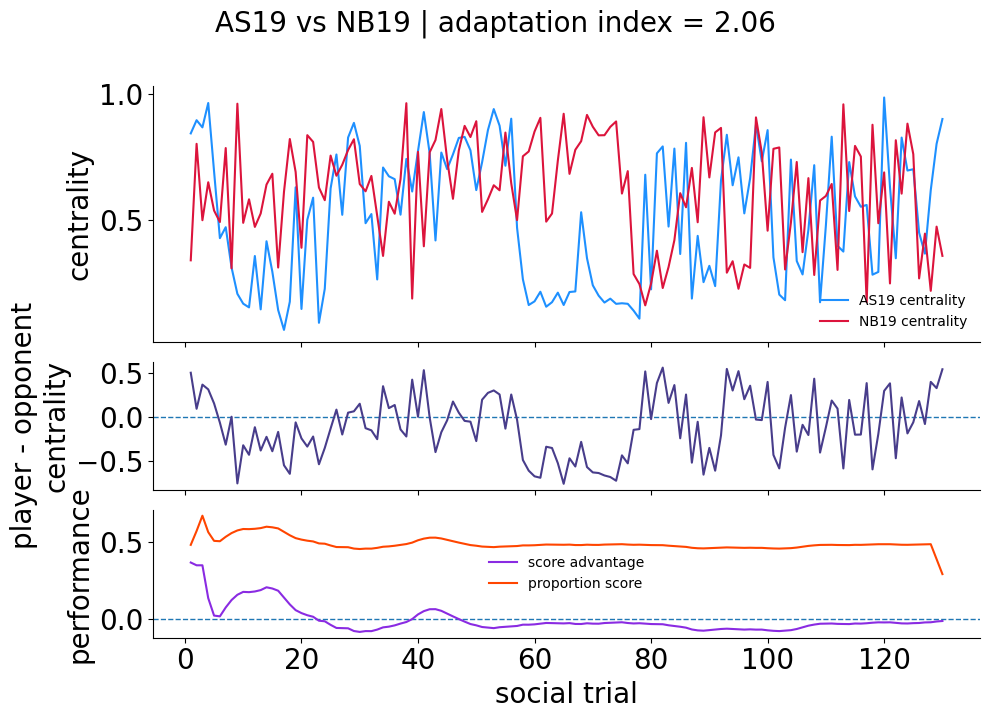

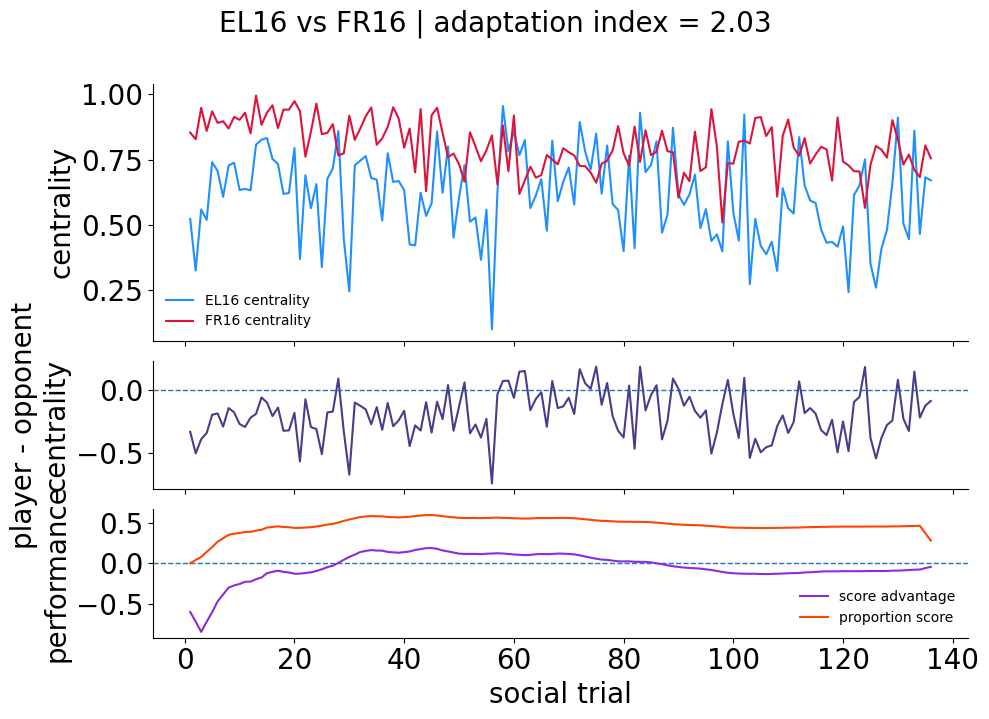

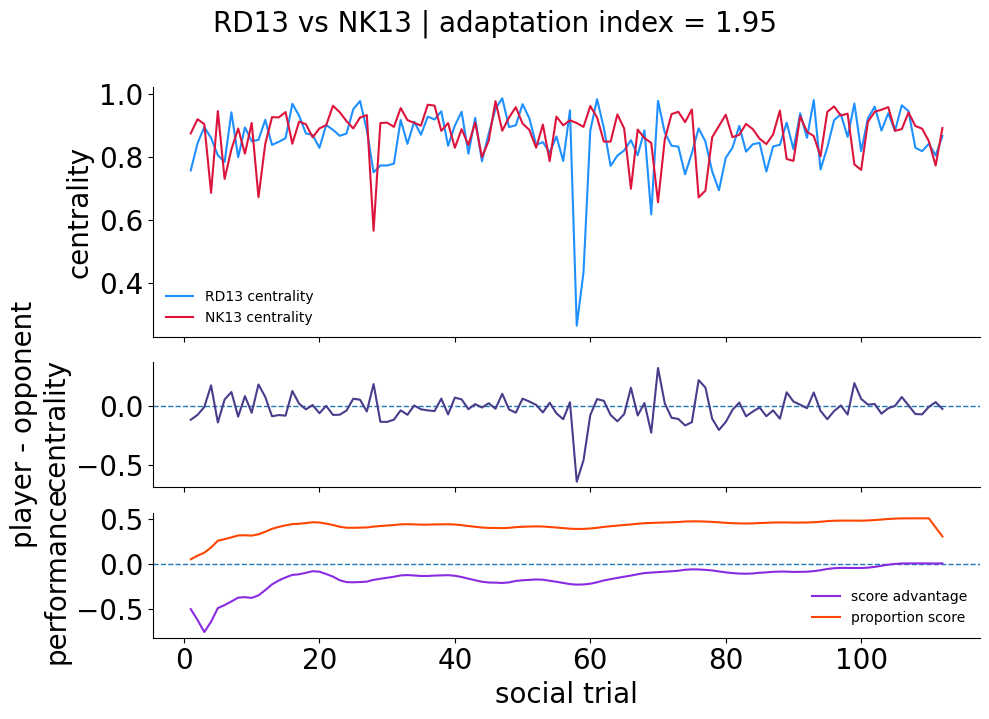

In [81]:
for pseudo in pseudonyms:
    plot_slow_adapter_session(
        pseudo,
        occupancy_dict,
        rolling_metrics_by_pseudonym,
        trait_df=trait_df,
        drop_first_trial=True,
        smooth_window=5
    )

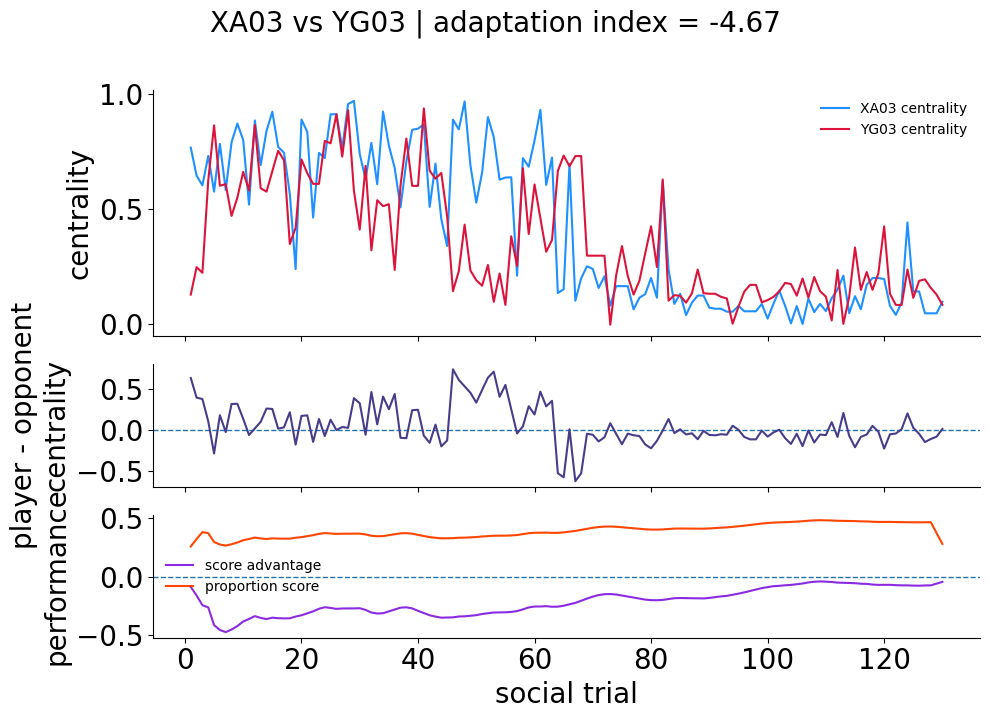

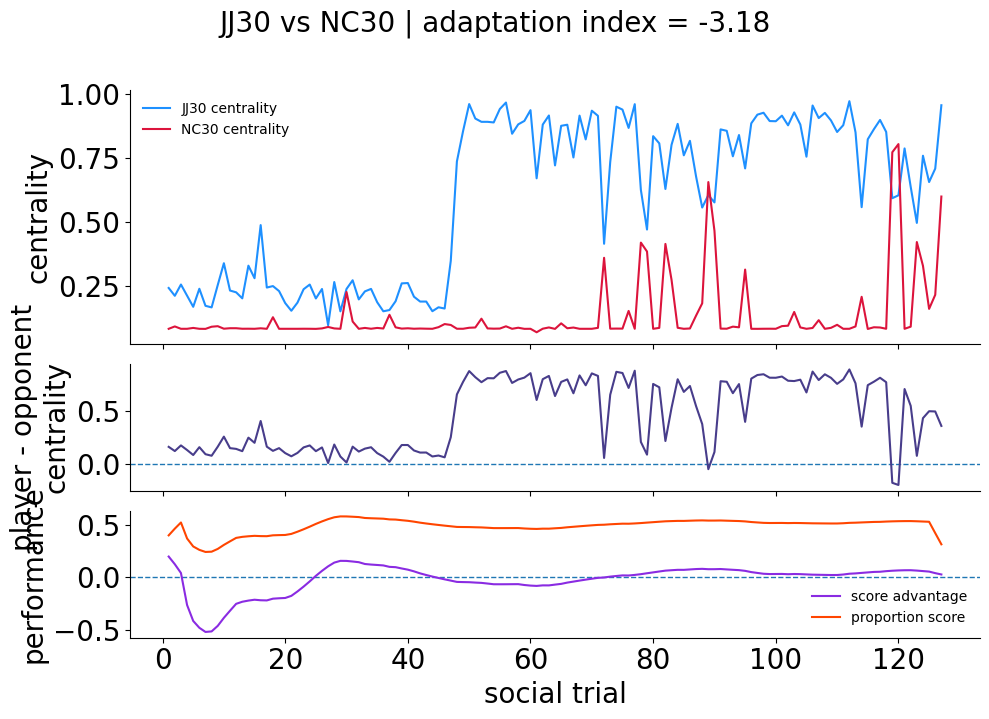

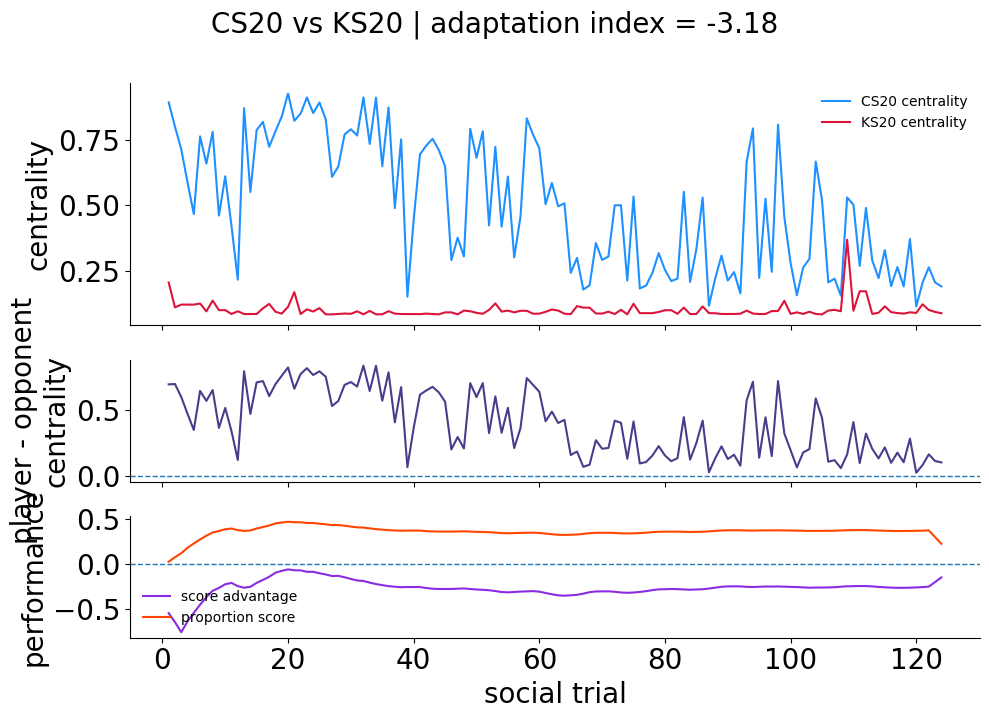

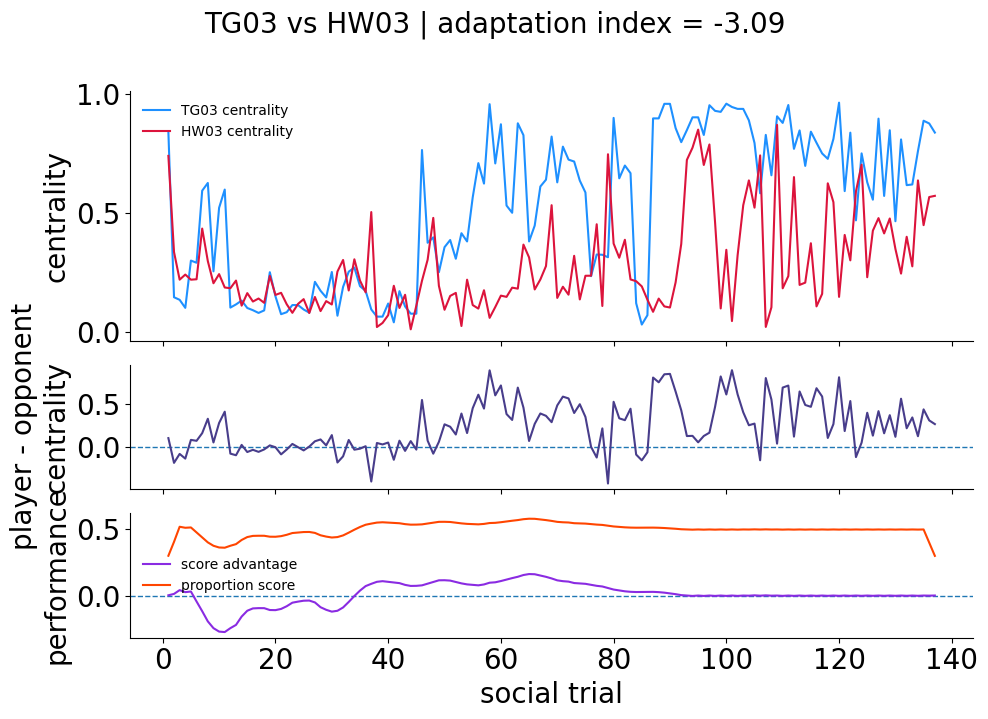

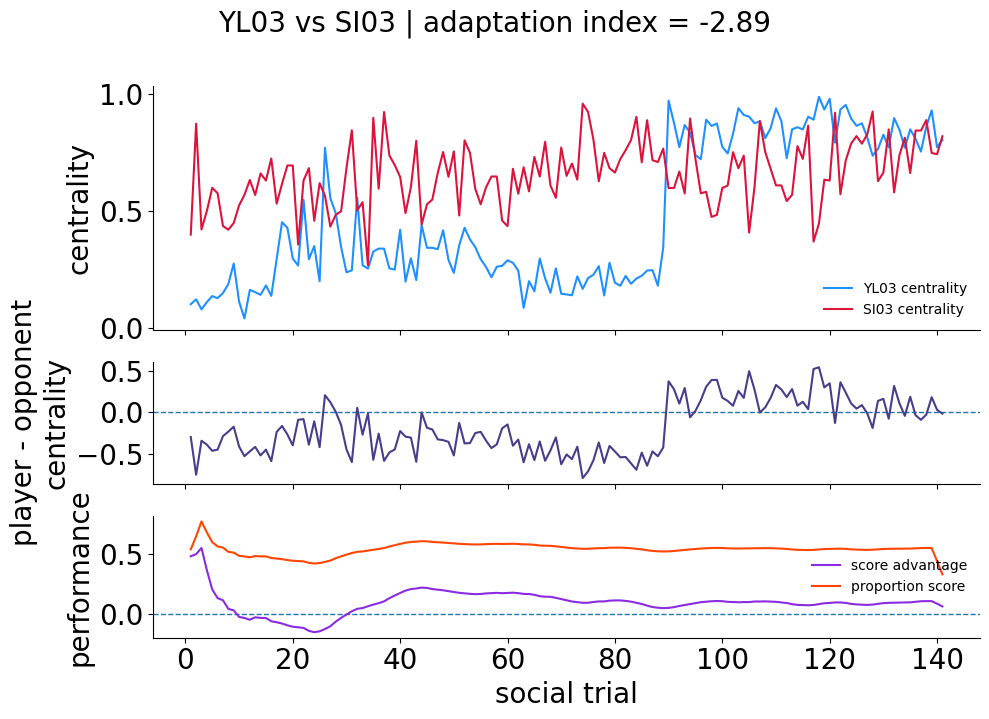

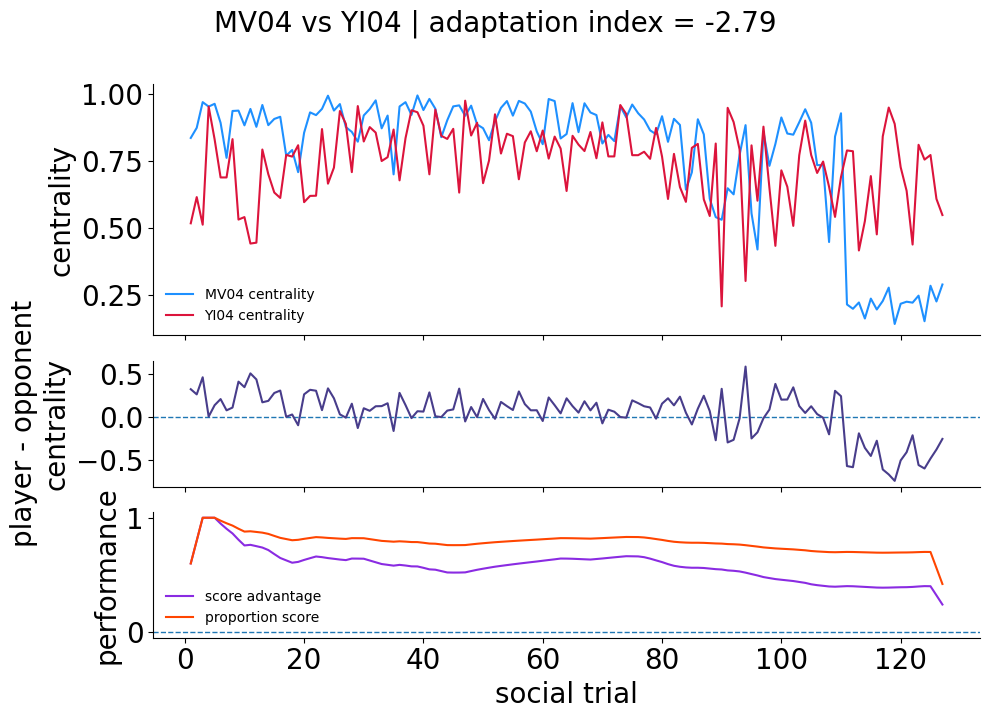

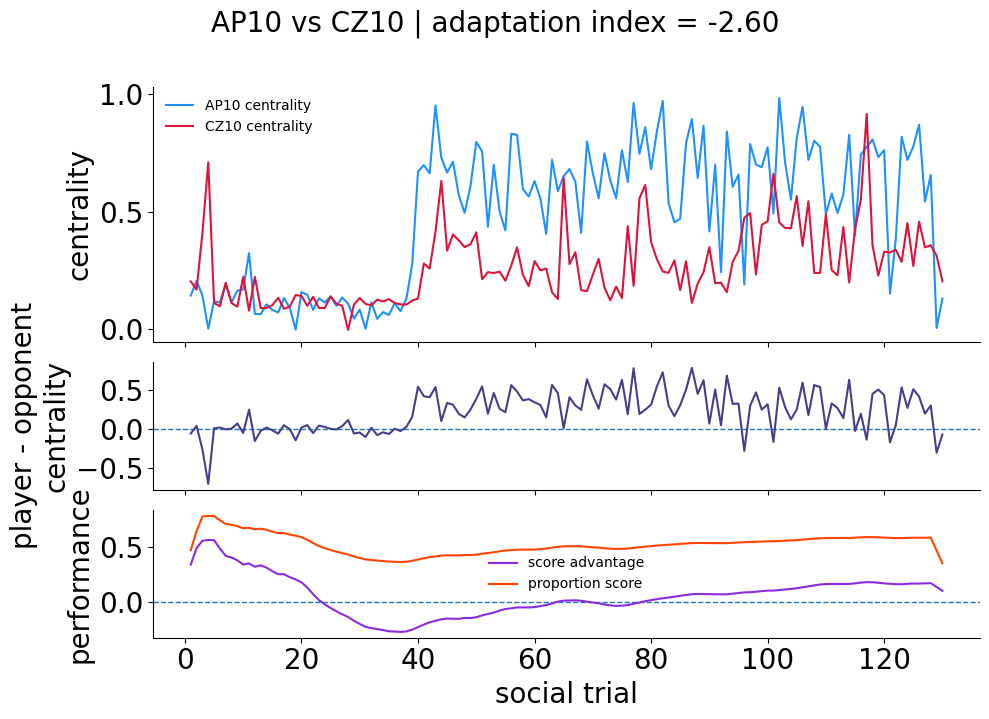

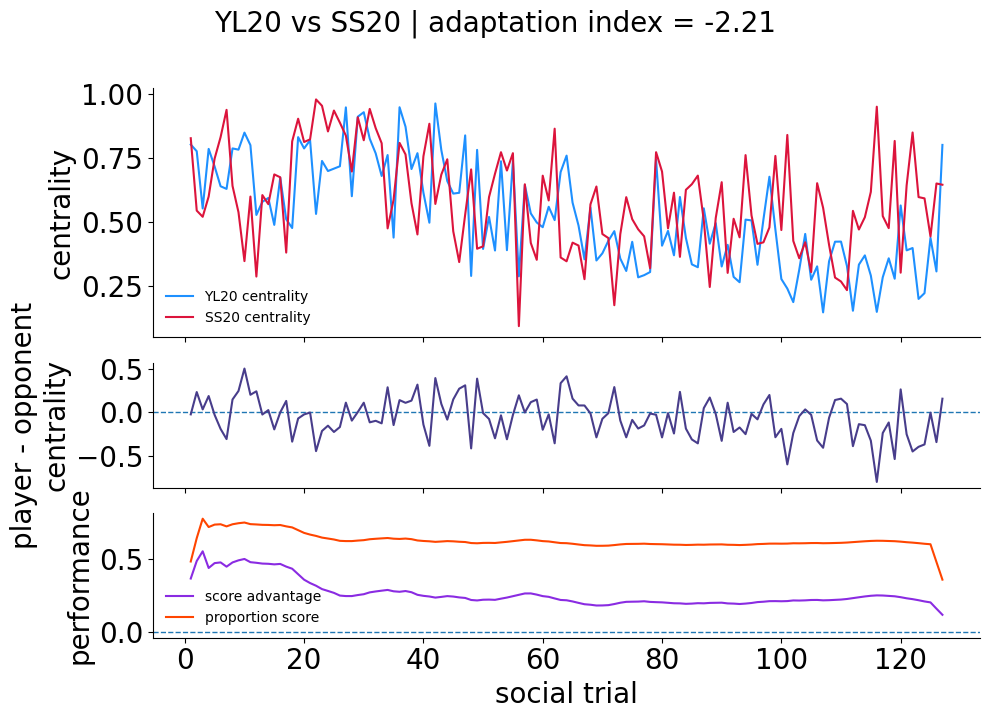

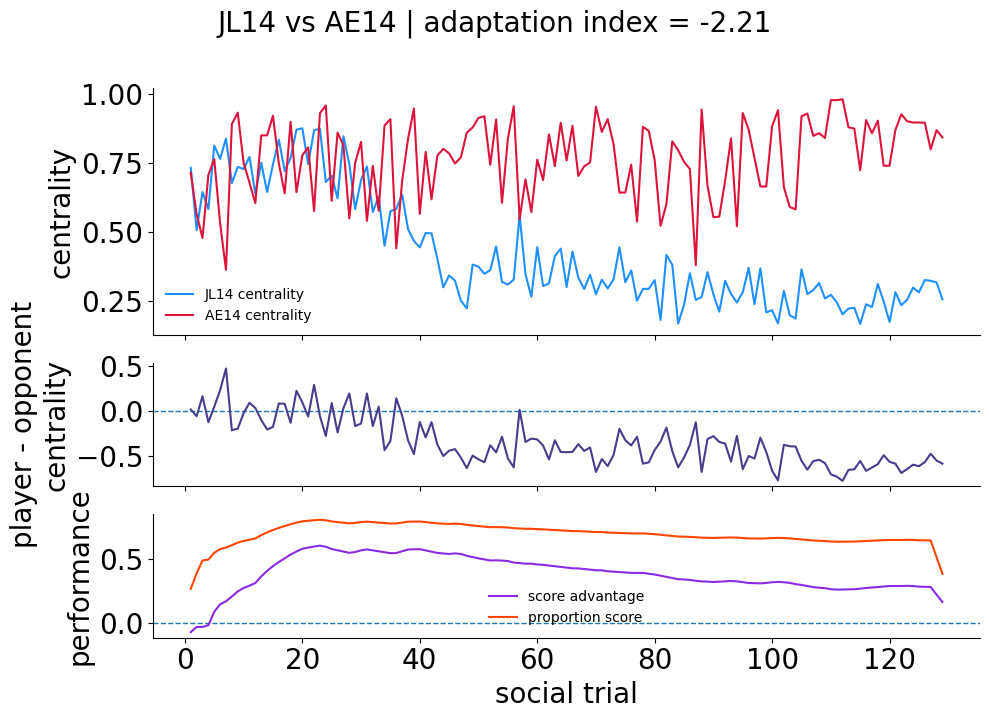

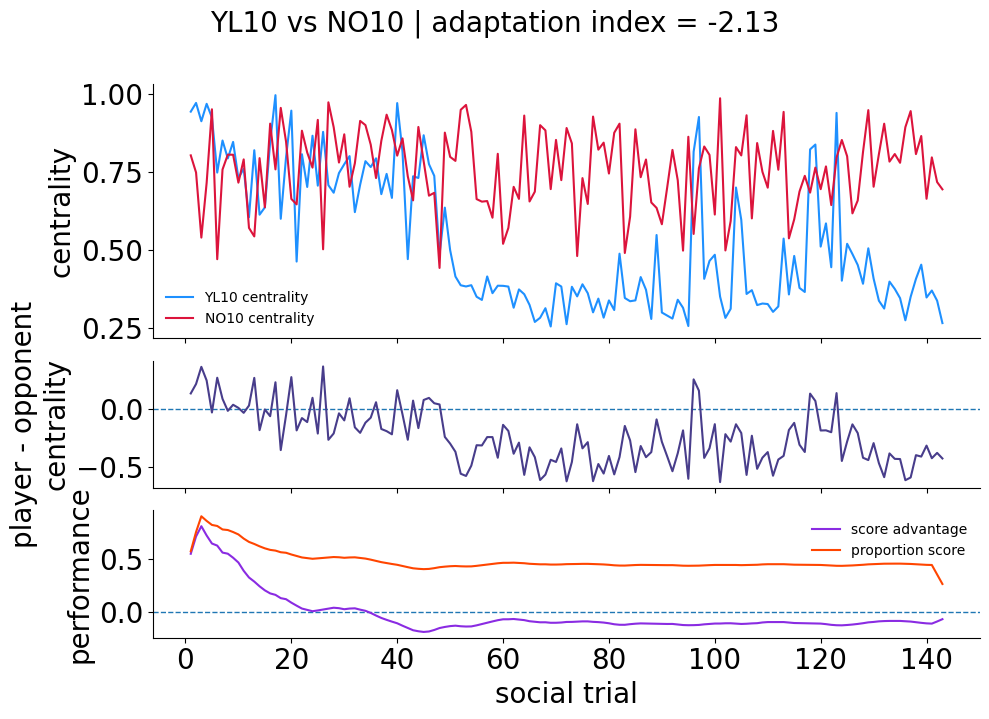

In [83]:
for pseudo in pseudonyms:
    plot_slow_adapter_session(
        pseudo,
        occupancy_dict,
        rolling_metrics_by_pseudonym,
        trait_df=trait_df,
        drop_first_trial=True,
        smooth_window=5
    )

In [ ]:
# bottom quartile
slow_adapters = ui[
    ui < np.percentile(ui, 25)
]

In [ ]:
# correlating slow adapter score with performance late vs early in the session

In [ ]:
# I need an array for proportion score at each trial during the social session
# I could plot all starting positions and color by proporion score